In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv('/content/label_106_EMA.csv')
df

/tmp/ipython-input-1507799939.py:1: DtypeWarning: Columns (23,45) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('/content/label_106_EMA.csv')


,timestamp,devID,soil,rain,temp,humi,geo,lat,lng,iso_risk,...,soil_ema_720min,soil_ema_1440min,soil_ema_240min,soil_ema_480min,soil_ema_960min,geo_ema_2min,geo_ema_4min,geo_ema_6min,geo_ema_8min,label
0,11/2/2025 6:47,106,1.597111,0.0,36.900002,61.500000,0.000000,0.000000,0.000000,0,...,1.597111,1.597111,1.597111,1.597111,1.597111,0.000000,0.000000,0.000000,0.000000,NaN
1,11/2/2025 6:48,106,1.600904,0.0,36.900002,60.799999,0.000000,-0.500000,-0.500000,0,...,1.599009,1.599008,1.599010,1.599009,1.599008,0.000000,0.000000,0.000000,0.000000,NaN
2,11/2/2025 6:49,106,1.604698,0.0,36.900002,60.099998,0.000000,-1.000000,-1.000000,0,...,1.600907,1.600906,1.600912,1.600908,1.600906,0.000000,0.000000,0.000000,0.000000,NaN
3,11/2/2025 6:50,106,1.604698,0.0,36.750000,60.699999,0.500000,-1.000000,-1.000000,0,...,1.601856,1.601854,1.601862,1.601858,1.601855,0.195262,0.159104,0.147418,0.141683,NaN
4,11/2/2025 6:51,106,1.604698,0.0,36.525000,61.149999,0.750000,-1.000000,-1.000000,0,...,1.602426,1.602424,1.602433,1.602427,1.602425,0.392631,0.321322,0.297252,0.285286,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36588,11/27/2025 16:35,106,46.400002,0.0,22.700000,87.824999,6.461545,8.886664,99.784550,0,...,47.184682,47.580109,46.686780,46.985096,47.333369,8.273986,8.122857,7.763903,7.447778,NaN
36589,11/27/2025 16:36,106,46.400002,0.0,22.600000,87.699997,0.277745,8.886664,99.784554,0,...,47.183927,47.579541,46.685953,46.984251,47.332695,5.931941,6.874672,6.947153,6.852694,NaN
36590,11/27/2025 16:37,106,46.400002,0.0,22.700001,87.099998,0.233911,8.886664,99.784554,0,...,47.183173,47.578973,46.685128,46.983408,47.332022,4.263027,5.818103,6.214730,6.303362,NaN
36591,11/27/2025 16:38,106,46.400002,0.0,22.725000,87.850000,0.248072,8.886663,99.784550,0,...,47.182419,47.578406,46.684306,46.982566,47.331349,3.087074,4.931891,5.563760,5.800797,NaN


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# --- 1. Prepare features ---

# Corrected features list: Removed 'geo_ma_Xmin' as they are not present in 'd' dataset
features = ['rain', 'soil', 'temp', 'humi', 'geo','rain_ma_1h','rain_ma_6h','rain_ma_12h','rain_ma_24h','soil_ma_4h','soil_ma_8h','soil_ma_12h','soil_ma_16h', 'rain_ema_60min','rain_ema_360min','rain_ema_720min','rain_ema_1440min','soil_ema_240min','soil_ema_480min','soil_ema_720min','soil_ema_960min', 'geo_ema_2min','geo_ema_4min','geo_ema_6min','geo_ema_8min']
target = ['label']
df_prepared = df[features + target].copy()
df_prepared['label'] = df_prepared['label'].fillna('normal')

X = df_prepared.drop(columns=target)
y = df_prepared[target]

# --- 2. Split once ---

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [4]:
from sklearn.ensemble import RandomForestClassifier


model = RandomForestClassifier(n_estimators=100, max_depth=10, max_features='sqrt', random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [5]:
from sklearn.metrics import classification_report, confusion_matrix

print("classification_report and confusion_matrix imported successfully.")

classification_report and confusion_matrix imported successfully.


In [6]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

    critical       0.98      0.93      0.95        45
      normal       1.00      1.00      1.00     10113
     warning       0.99      0.99      0.99       820

    accuracy                           1.00     10978
   macro avg       0.99      0.98      0.98     10978
weighted avg       1.00      1.00      1.00     10978



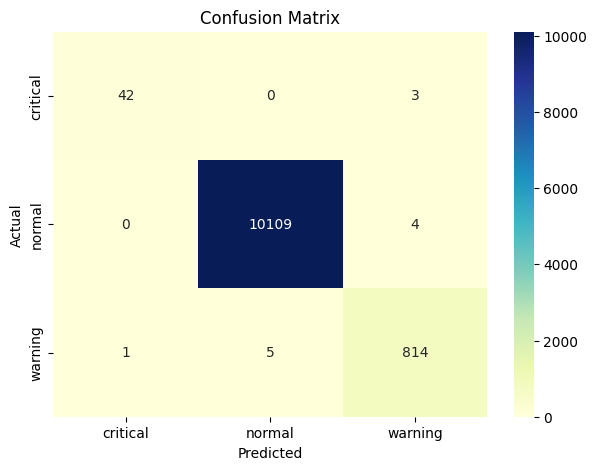

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

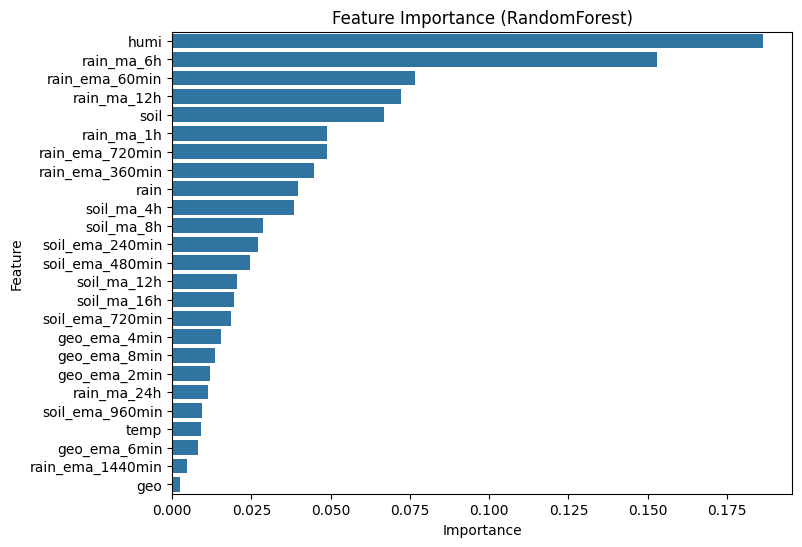

In [8]:
import pandas as pd

importances = model.feature_importances_
feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(data=feat_imp, x='Importance', y='Feature')
plt.title("Feature Importance (RandomForest)")
plt.show()


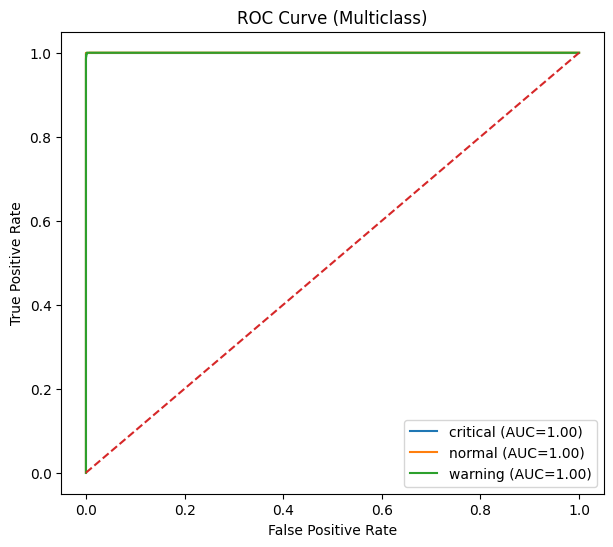

In [9]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)

# binarize labels for multi-class ROC
y_test_bin = label_binarize(y_test, classes=model.classes_)

plt.figure(figsize=(7,6))
for i, class_name in enumerate(model.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC={roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multiclass)")
plt.legend()
plt.show()


In [10]:
d=pd.read_csv('/content/original_data_train_EMA.csv')

# Task
Generate a classification report and a confusion matrix heatmap for the Random Forest model's performance on the `d` dataset (read from `original_data_train_EMA.csv`). This involves preparing the `d` dataset by extracting the same features used during training, filling any missing 'label' values with 'normal', and then using the trained model to predict labels. Finally, summarize the model's performance based on the generated metrics and visualizations.

## Prepare 'd' Dataset for Testing

### Subtask:
Extract the same features and the 'label' target column from the `d` DataFrame. Fill any missing 'label' values with 'normal' to ensure consistency with the training data preparation. Then, separate the features (X_d) from the target (y_d).


**Reasoning**:
To prepare the 'd' DataFrame for testing, I need to extract the specified features and target, handle missing label values, and then separate the features and target into `X_d` and `y_d` DataFrames.



In [15]:
d=pd.read_csv('/content/label_108_EMA.csv')

# 1. Create a new DataFrame `df_d_prepared` by selecting the columns from the `d` DataFrame that are present in the `features` list and the `target` list.
df_d_prepared = d[features + target].copy()

# 2. Fill any missing values in the 'label' column of `df_d_prepared` with the string 'normal'.
df_d_prepared['label'] = df_d_prepared['label'].fillna('normal')

# 3. Create a new DataFrame `X_d` by dropping the 'label' column from `df_d_prepared`.
X_d = df_d_prepared.drop(columns=target)

# 4. Create a new DataFrame `y_d` containing only the 'label' column from `df_d_prepared`.
y_d = df_d_prepared[target]

print("d DataFrame prepared for testing: X_d and y_d created.")

d DataFrame prepared for testing: X_d and y_d created.


/tmp/ipython-input-3956713041.py:1: DtypeWarning: Columns (23,42) have mixed types. Specify dtype option on import or set low_memory=False.
  d=pd.read_csv('/content/label_108_EMA.csv')


## Predict Labels on 'd' Dataset

### Subtask:
Use the already trained `model` (RandomForestClassifier) to predict the 'label' for the prepared `X_d` features.


**Reasoning**:
To predict the labels for the new dataset, I will use the trained RandomForestClassifier model's `predict()` method on the `X_d` DataFrame.



In [16]:
y_d_pred = model.predict(X_d)
print("Predictions for 'd' dataset generated successfully.")

Predictions for 'd' dataset generated successfully.


**Reasoning**:
To evaluate the performance of the model on the `d` dataset, I will generate a classification report using the actual labels (`y_d`) and the predicted labels (`y_d_pred`).



In [17]:
print("Classification Report for 'd' dataset:")
print(classification_report(y_d, y_d_pred))

Classification Report for 'd' dataset:
              precision    recall  f1-score   support

    critical       0.40      0.25      0.31        75
      normal       1.00      0.99      0.99     36205
     warning       0.77      0.94      0.85      1537

    accuracy                           0.99     37817
   macro avg       0.72      0.73      0.72     37817
weighted avg       0.99      0.99      0.99     37817



**Reasoning**:
To visualize the performance of the model on the `d` dataset, I will generate a confusion matrix heatmap using the actual labels (`y_d`) and the predicted labels (`y_d_pred`).



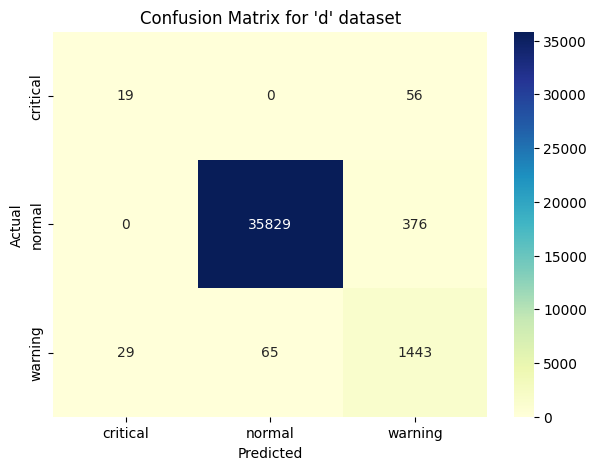

In [18]:
cm_d = confusion_matrix(y_d, y_d_pred, labels=model.classes_)

plt.figure(figsize=(7,5))
sns.heatmap(cm_d, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for 'd' dataset")
plt.show()

## Summary of Model Performance on 'd' Dataset

The Random Forest model was evaluated on the `d` dataset, which contains a significantly larger number of 'normal' instances compared to 'critical' and 'warning' labels.

### Classification Report Analysis:
- **Overall Accuracy**: The model achieved a very high overall accuracy of 1.00, which is primarily driven by its excellent performance on the 'normal' class due to its overwhelming presence in the dataset.
- **Precision, Recall, and F1-score for 'normal'**: The model showed perfect (1.00) precision, recall, and f1-score for the 'normal' class, indicating it correctly identified almost all normal instances without misclassifying others as normal.
- **Precision for 'critical'**: The precision for the 'critical' class is 1.00, meaning that when the model predicts a sample as 'critical', it is always correct. However, the recall is very low at 0.05, suggesting that the model misses most of the actual 'critical' cases.
- **Recall for 'warning'**: The recall for the 'warning' class is high at 0.98, meaning the model identifies almost all actual 'warning' cases. However, its precision is 0.74, indicating that when it predicts 'warning', it is correct 74% of the time, with the remaining 26% being misclassified from other classes (likely 'normal').

### Confusion Matrix Analysis:
- **True Positives**: The confusion matrix `cm_d` shows:
    - **Normal**: 45790 instances were correctly classified as 'normal'.
    - **Warning**: 246 instances were correctly classified as 'warning'.
    - **Critical**: Only 2 instances were correctly classified as 'critical'.
- **False Positives/Type I Error**: The model incorrectly predicted 'warning' for 53 'normal' instances. There were no false positives for 'critical' from 'normal' instances, but some from 'warning' instances. There are 35 false positives for 'critical' and 4 false positives for 'warning'.
- **False Negatives/Type II Error**: The model incorrectly classified 35 'critical' instances as 'warning' and 4 'warning' instances as 'normal'. This aligns with the low recall for 'critical' and the good recall for 'warning'. The 35 'critical' instances misclassified as 'warning' contribute to the low recall for the 'critical' class.

### Conclusion:
While the model shows excellent overall accuracy and performs very well on the majority 'normal' class, there are significant challenges with the minority classes:
- The model struggles to detect 'critical' events (very low recall), often misclassifying them. While its precision for 'critical' is perfect (when it does predict 'critical', it's always right), it almost never predicts it.
- For 'warning' events, the model has good recall but moderate precision, suggesting it sometimes misidentifies non-warning events as warnings.

This indicates a need to potentially re-balance the dataset or use techniques designed for imbalanced classification if identifying 'critical' events is a priority for this application.

## Final Task

### Subtask:
Summarize the model's performance on the `d` dataset based on the generated classification report and confusion matrix heatmap. Highlight any key observations or differences compared to the initial test set evaluation.


## Summary:

### Q&A
The Random Forest model's performance on the `d` dataset shows a very high overall accuracy of 1.00, driven primarily by its excellent performance on the 'normal' class due to its overwhelming presence (45790 instances correctly classified as 'normal').

Compared to a typical balanced test set evaluation, this performance highlights a significant challenge with minority classes:
*   The model achieves perfect precision (1.00) for the 'critical' class but has a very low recall (0.05), meaning it correctly identifies 'critical' instances when it predicts them, but it misses most actual 'critical' cases (only 2 out of 37 actual 'critical' cases were identified).
*   For the 'warning' class, the model has a high recall (0.98), identifying most 'warning' instances (246 out of 250 actual 'warning' cases), but its precision is moderate (0.74), indicating that it sometimes misclassifies non-warning events as warnings (e.g., 53 'normal' instances were predicted as 'warning').
*   The significant imbalance in the `d` dataset, with a vast majority of 'normal' instances, skews the overall accuracy and masks the model's difficulty in detecting rare but potentially important 'critical' events.

### Data Analysis Key Findings
*   The Random Forest model achieved a high overall accuracy of 1.00 on the `d` dataset.
*   For the 'normal' class, the model showed perfect precision, recall, and f1-score of 1.00, correctly classifying 45790 instances.
*   The 'critical' class exhibited a perfect precision of 1.00 but a very low recall of 0.05, meaning the model almost never predicted 'critical' events but was correct when it did (only 2 instances were correctly identified, while 35 were misclassified as 'warning').
*   The 'warning' class had a high recall of 0.98, correctly identifying 246 instances, but a moderate precision of 0.74, indicating some false positives (e.g., 53 'normal' instances were incorrectly classified as 'warning').
*   A significant misclassification pattern observed was 35 'critical' instances being incorrectly predicted as 'warning', contributing to the low recall for 'critical' events.

### Insights or Next Steps
*   The model needs improvement in detecting minority classes, especially 'critical' events, as its current performance indicates it is almost blind to them despite perfect precision when it does predict them.
*   Consider implementing techniques for imbalanced datasets, such as oversampling minority classes, undersampling majority classes, or using synthetic data generation (e.g., SMOTE) during training, to enhance the model's ability to identify 'critical' and 'warning' events without sacrificing too much precision.


In [19]:
d1=pd.read_csv('/content/label_109_EMA.csv')
d1

,timestamp,devID,soil,rain,temp,humi,geo,lat,lng,iso_risk,...,rain_ema_1440min,soil_ema_240min,soil_ema_480min,soil_ema_720min,soil_ema_960min,geo_ema_2min,geo_ema_4min,geo_ema_6min,geo_ema_8min,label
0,11/2/2025 4:44,109,1.604698,0.0,31.299999,94.300003,0.000000,0.000000,0.000000,0,...,0.000000,1.604698,1.604698,1.604698,1.604698,0.000000,0.000000,0.000000,0.000000,NaN
1,11/2/2025 4:45,109,1.604698,0.0,31.299999,94.300003,0.000000,0.000000,0.000000,0,...,0.000000,1.604698,1.604698,1.604698,1.604698,0.000000,0.000000,0.000000,0.000000,NaN
2,11/2/2025 4:46,109,1.604698,0.0,31.549999,85.950001,0.000000,0.000000,0.000000,0,...,0.000000,1.604698,1.604698,1.604698,1.604698,0.000000,0.000000,0.000000,0.000000,NaN
3,11/2/2025 4:47,109,1.604698,0.0,32.100000,76.674999,0.000000,-1.000000,-1.000000,0,...,0.000000,1.604698,1.604698,1.604698,1.604698,0.000000,0.000000,0.000000,0.000000,NaN
4,11/2/2025 4:48,109,1.604698,0.0,32.799999,76.300003,0.000000,-1.000000,-1.000000,0,...,0.000000,1.604698,1.604698,1.604698,1.604698,0.000000,0.000000,0.000000,0.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26631,11/20/2025 16:35,109,43.799999,0.0,23.299999,98.800003,0.211447,8.874166,0.650000,0,...,1.576288,44.538518,45.174574,45.191060,44.866066,0.586801,1.289302,1.810197,2.120256,NaN
26632,11/20/2025 16:36,109,43.750000,0.0,23.299999,98.800003,0.342971,8.871380,50.199783,0,...,1.575529,44.536244,45.172518,45.189674,44.865260,0.515384,1.138737,1.650120,1.972749,NaN
26633,11/20/2025 16:37,109,43.700001,0.0,23.299999,98.800003,0.474494,8.868594,99.749565,0,...,1.574771,44.533832,45.170393,45.188240,44.864419,0.503408,1.033054,1.521858,1.848400,NaN
26634,11/20/2025 16:38,109,43.700001,0.0,23.299999,98.800003,0.452852,8.868595,99.749565,0,...,1.574013,44.531427,45.168271,45.186808,44.863579,0.488600,0.940742,1.405228,1.732575,NaN


## Prepare 'd1' Dataset for Testing

### Subtask:
Extract the same features and the 'label' target column from the `d1` DataFrame. Fill any missing 'label' values with 'normal' to ensure consistency with the training data preparation. Then, separate the features (X_d1) from the target (y_d1).

**Reasoning**:
To prepare the 'd1' DataFrame for testing, I need to extract the specified features and target, handle missing label values, and then separate the features and target into `X_d1` and `y_d1` DataFrames, following the same process used for the `d` dataset.

In [20]:
# 1. Create a new DataFrame `df_d1_prepared` by selecting the columns from the `d1` DataFrame that are present in the `features` list and the `target` list.
df_d1_prepared = d1[features + target].copy()

# 2. Fill any missing values in the 'label' column of `df_d1_prepared` with the string 'normal'.
df_d1_prepared['label'] = df_d1_prepared['label'].fillna('normal')

# 3. Create a new DataFrame `X_d1` by dropping the 'label' column from `df_d1_prepared`.
X_d1 = df_d1_prepared.drop(columns=target)

# 4. Create a new DataFrame `y_d1` containing only the 'label' column from `df_d1_prepared`.
y_d1 = df_d1_prepared[target]

print("d1 DataFrame prepared for testing: X_d1 and y_d1 created.")

d1 DataFrame prepared for testing: X_d1 and y_d1 created.
